## Классная работа

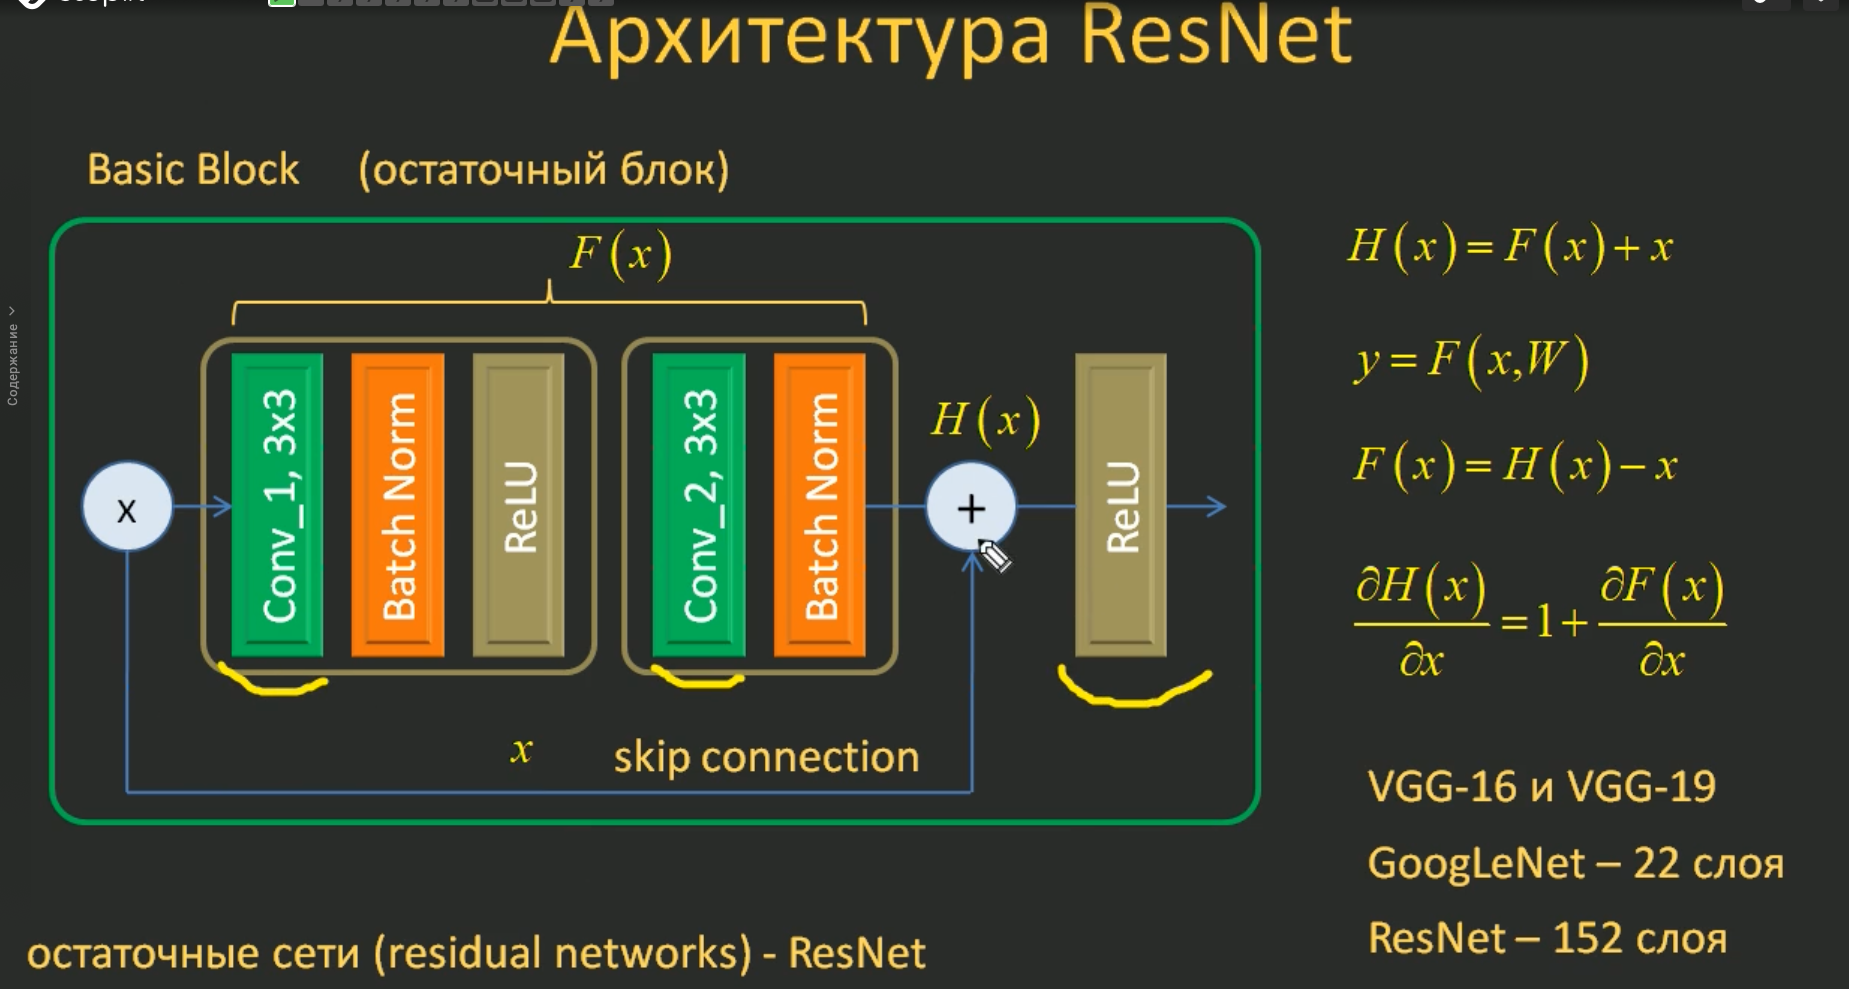

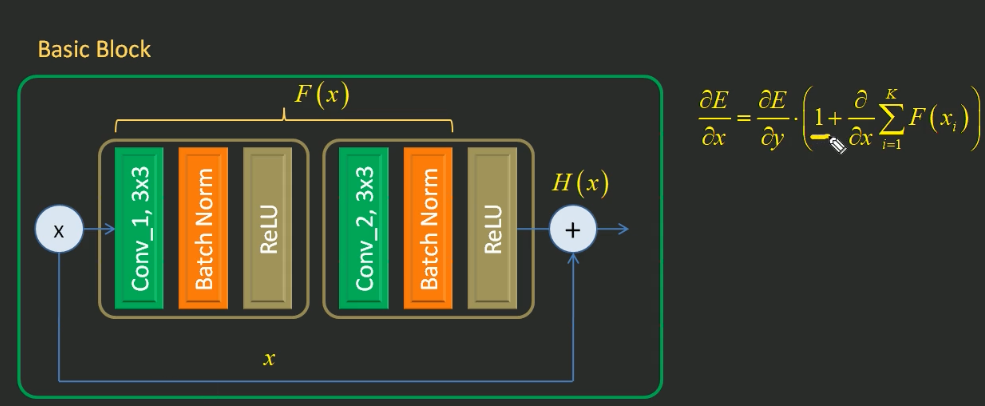

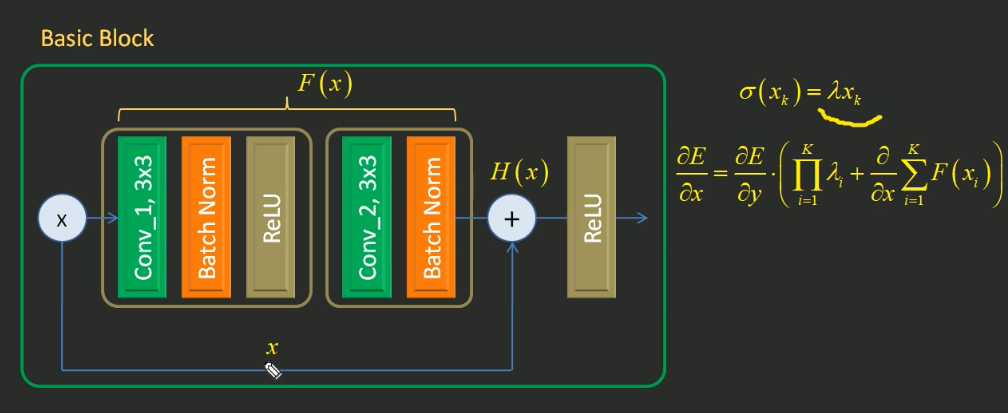

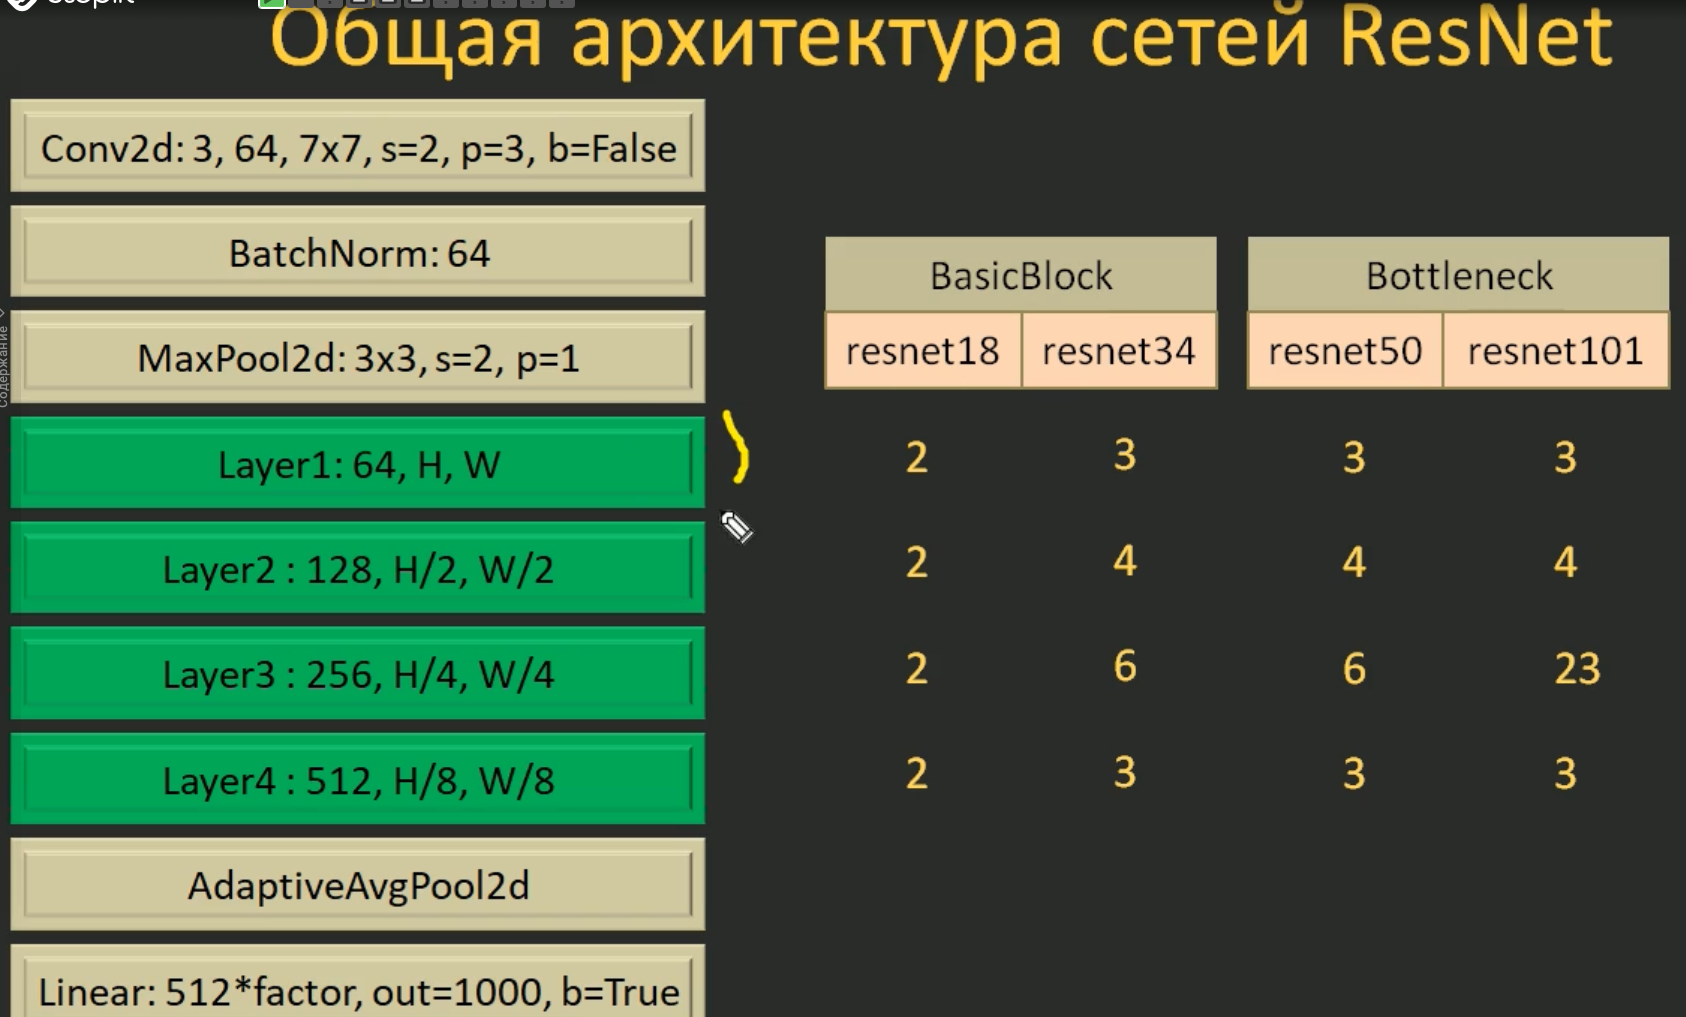

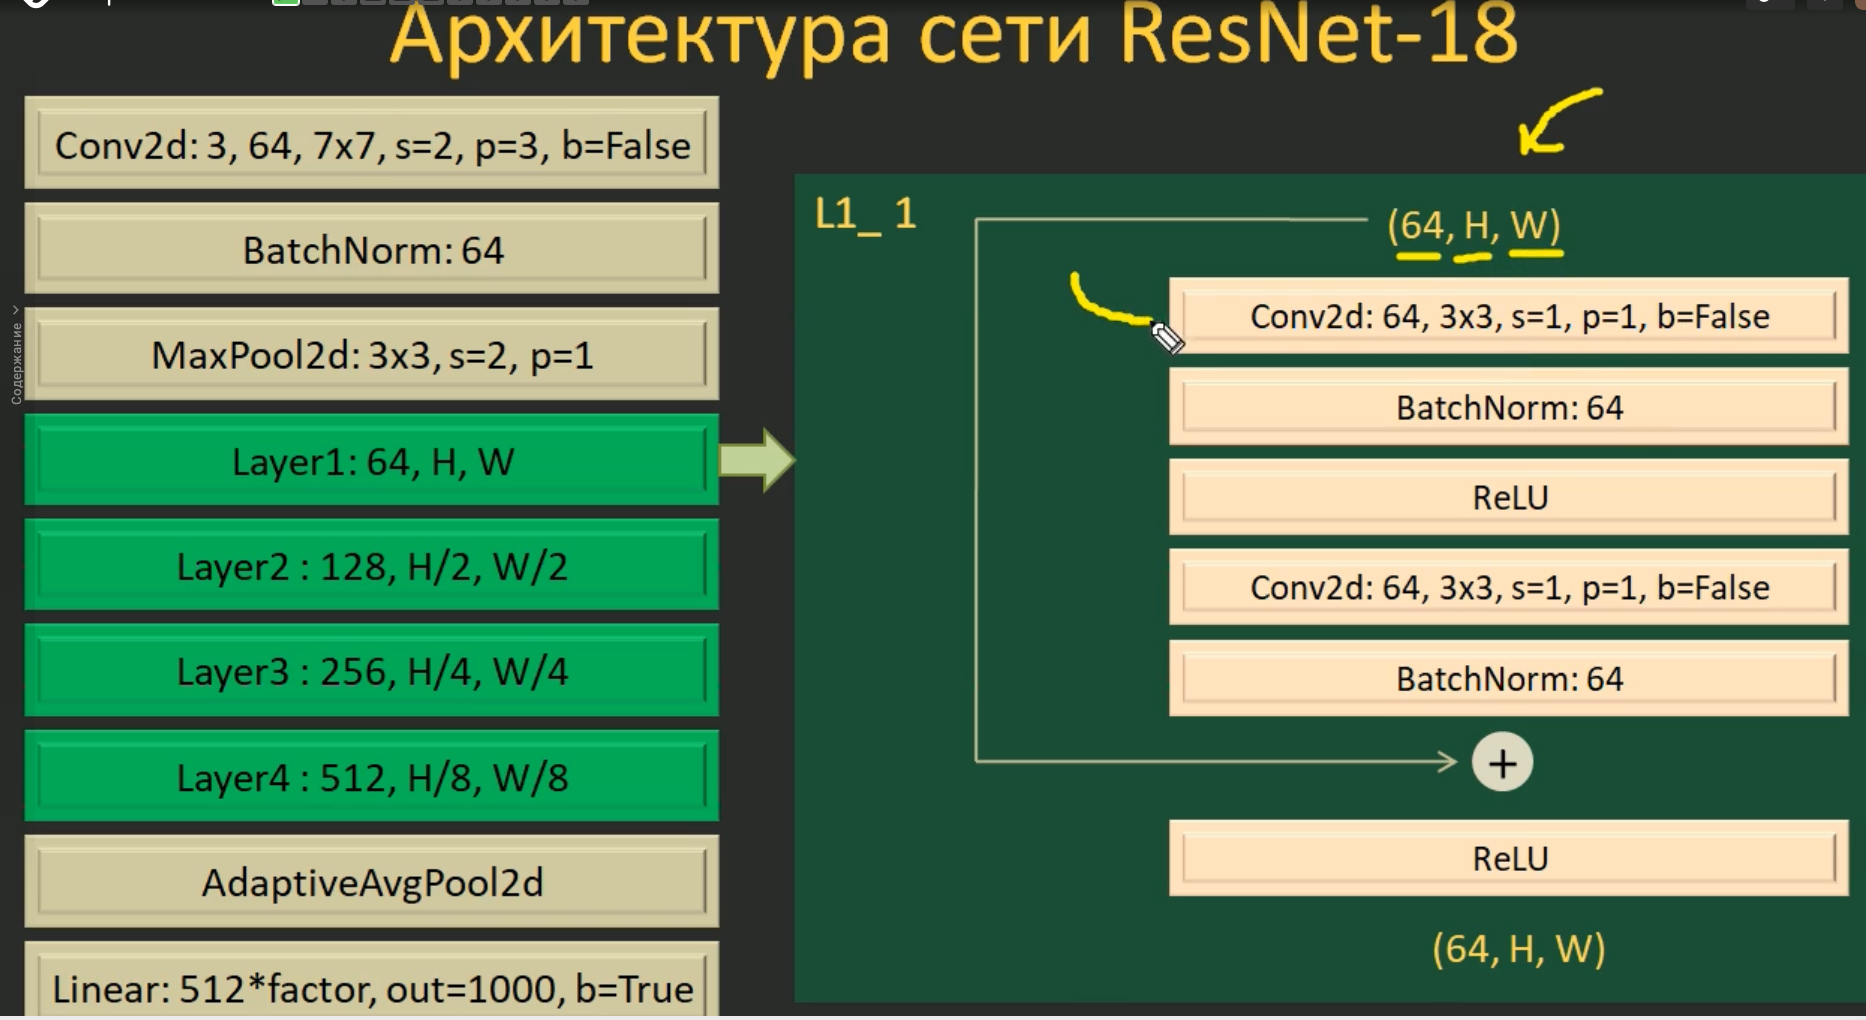

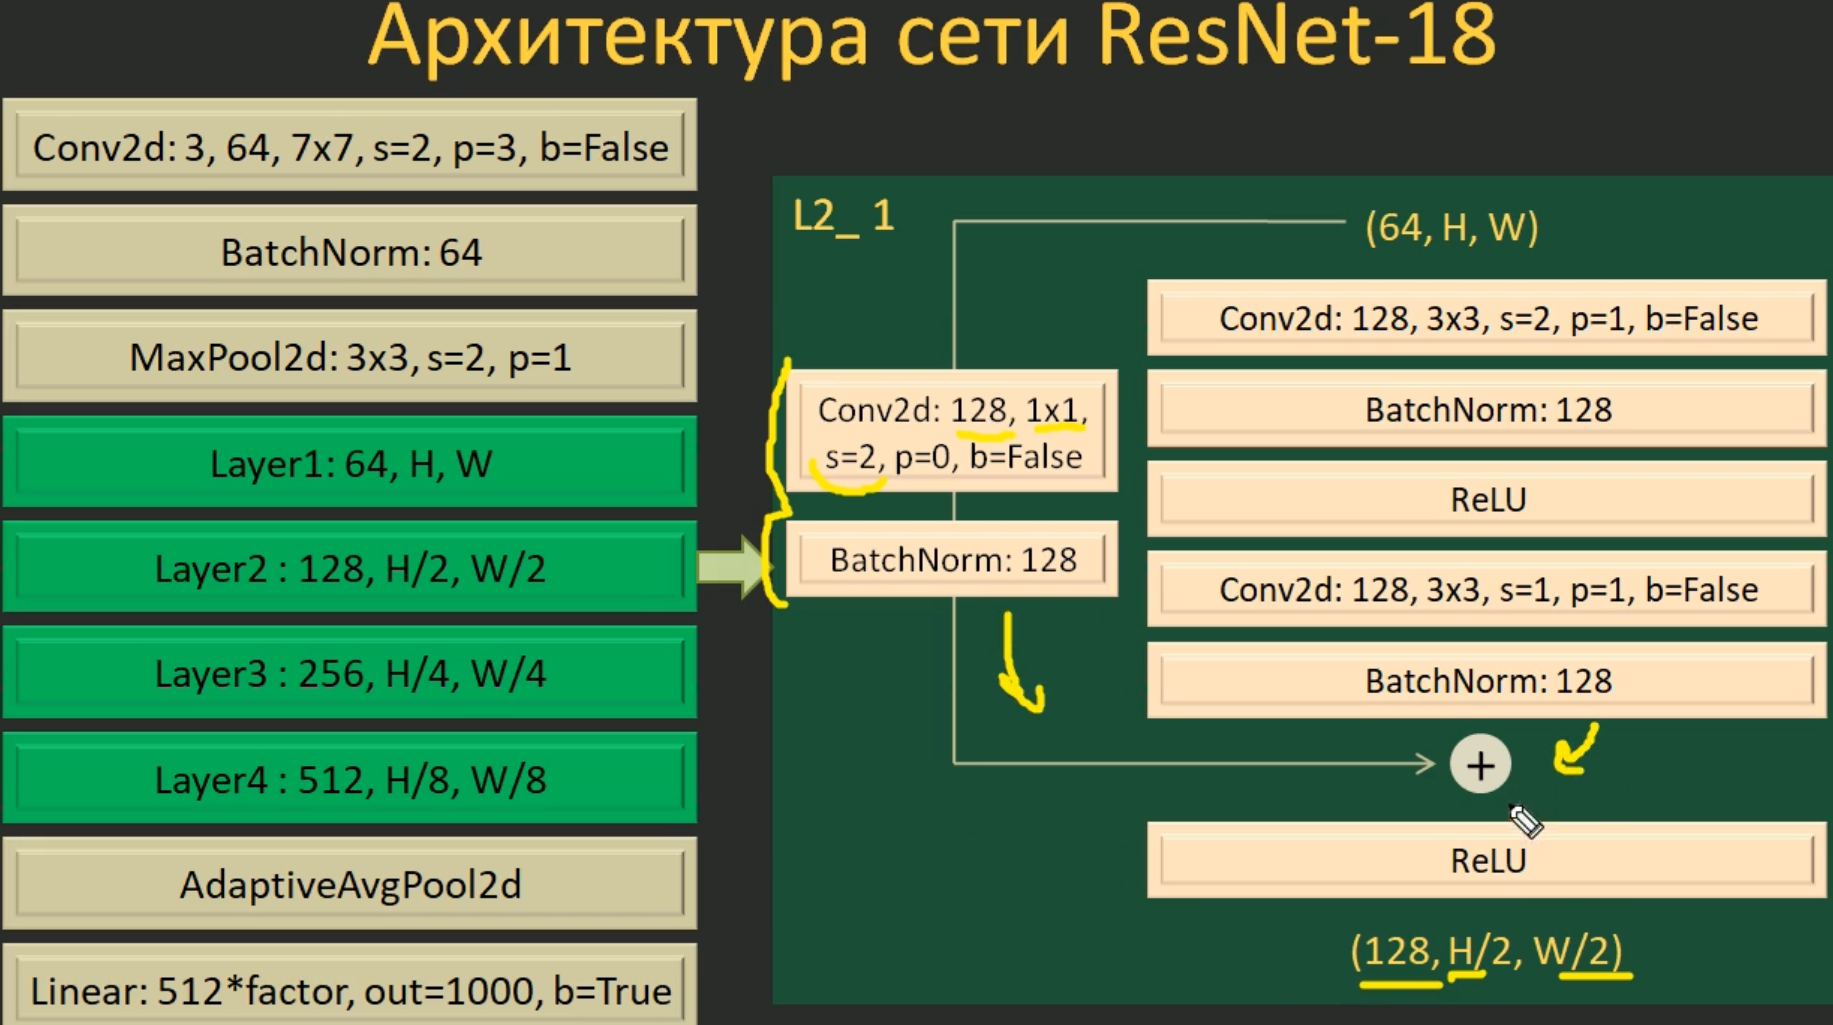

In [ ]:
import torch
import torch.nn as nn

from torchvision import models

from PIL import Image

In [27]:
weights = models.ResNet50_Weights.DEFAULT

In [ ]:
model = models.resnet50(weights=weights)
model.eval();

In [ ]:
cats = weights.meta['categories']
transforms = weights.transforms()

In [ ]:
img = Image.open('data/img_2.jpeg').convert("RGB")
img = transforms(img).unsqueeze(0)

In [ ]:
pred = model(img).squeeze()
res = pred.softmax(dim=0).sort(descending=True)

In [ ]:
for s, i in zip(res[0][:5], res[1][:5]):
  print(f"{cats[i]}: {s:.4f}")

## Домашняя работа

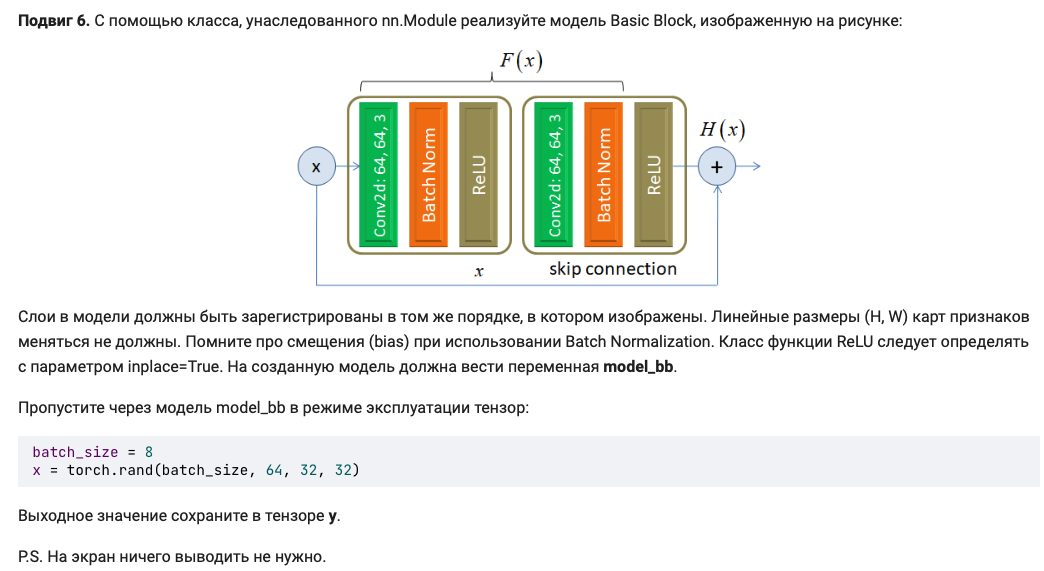

In [9]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели

batch_size = 8
x = torch.rand(batch_size, 64, 32, 32) # тензор x в программе не менять

# здесь продолжайте программу
class BasicBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(64, 64, 3, bias=False, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, bias=False, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = out + x
        return out
    
model_bb = BasicBlock()
model_bb.eval()
y = model_bb(x)

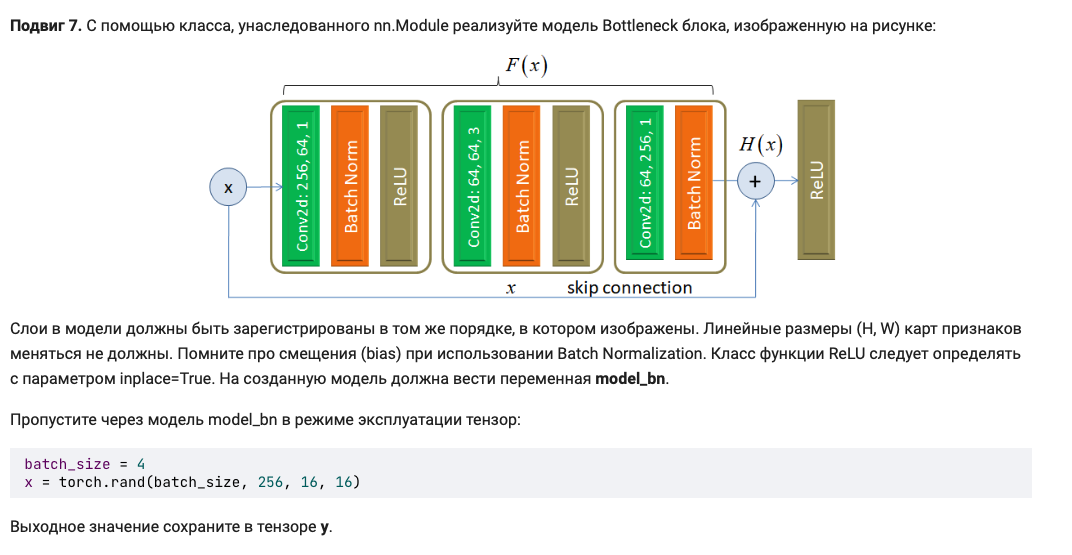

In [12]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели

batch_size = 4
x = torch.rand(batch_size, 256, 16, 16) # тензор x в программе не менять

# здесь продолжайте программу
class Bottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(256, 64, 1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 256, 1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out = out + x

        out = self.relu(out)

        return out

model_bn = Bottleneck()
model_bn.eval()
y = model_bn(x)
y.shape

torch.Size([4, 256, 16, 16])

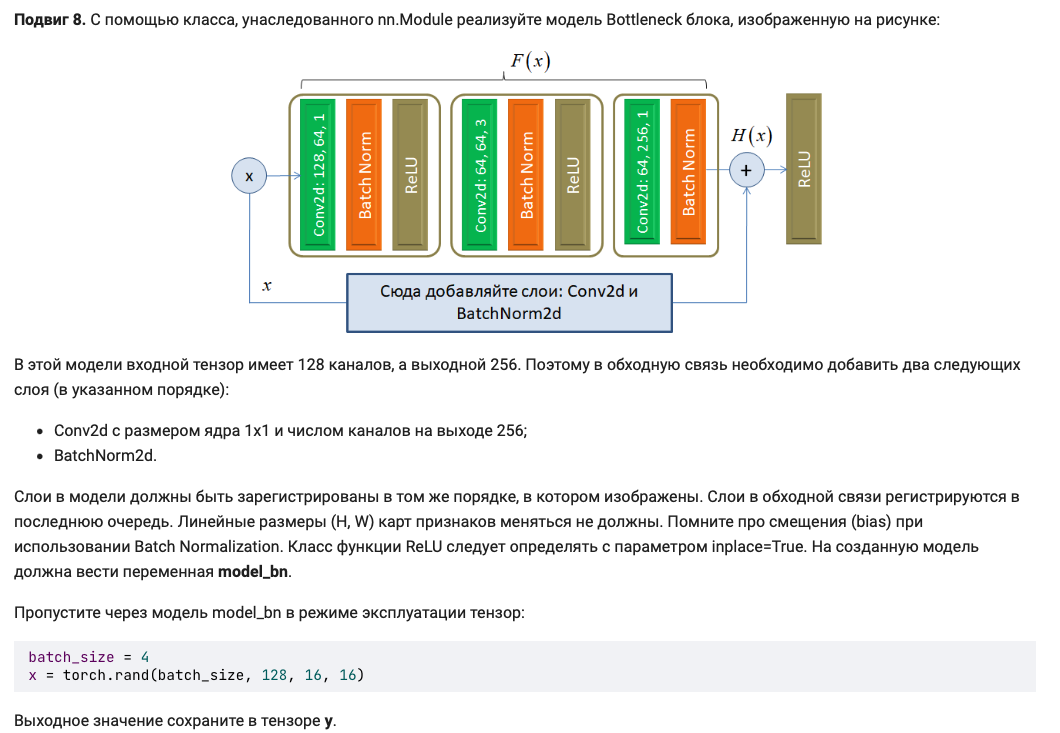

In [17]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели

batch_size = 4
x = torch.rand(batch_size, 128, 16, 16) # тензор x в программе не менять

# здесь продолжайте программу
class Bottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(128, 64, 1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 256, 1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU(inplace=True)

        self.convres = nn.Conv2d(128, 256, 1, padding=0, bias=False)
        self.bnres = nn.BatchNorm2d(256)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        outres = self.convres(x)
        outres = self.bnres(outres)

        out = out + outres

        out = self.relu(out)

        return out

model_bn = Bottleneck()
model_bn.eval()
y = model_bn(x)
y.shape

torch.Size([4, 256, 16, 16])

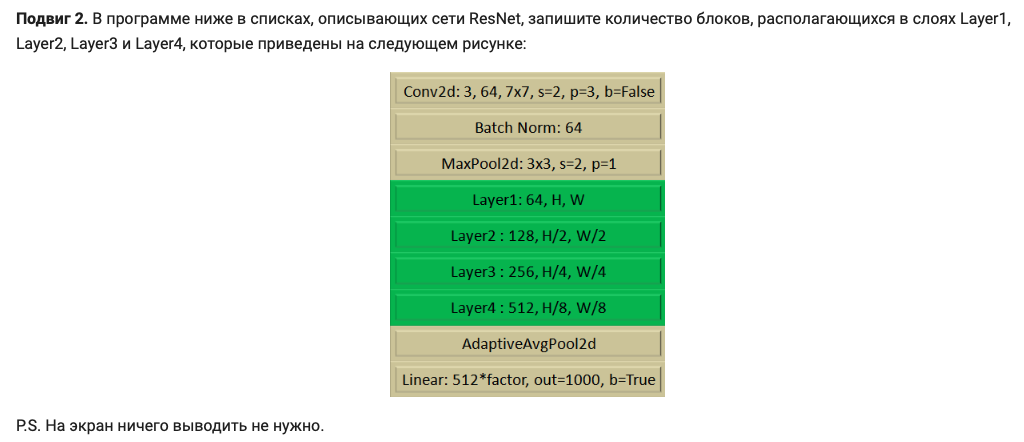

In [ ]:
# в каждом списке 4 значения - количество блоков (по порядку)
# в слоях Layer1, Layer2, Layer3 и Layer4
resnet18 = [2, 2, 2, 2]
resnet34 = [3, 4, 6, 3]
resnet50 = [3, 4, 6, 3]

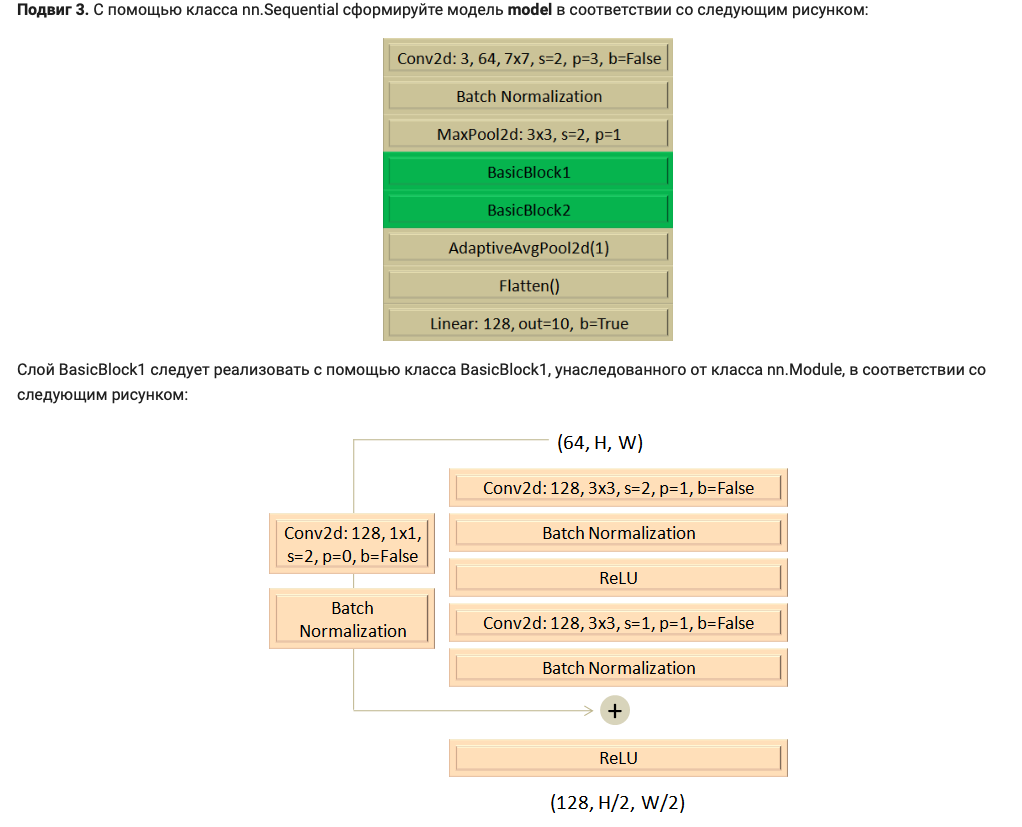
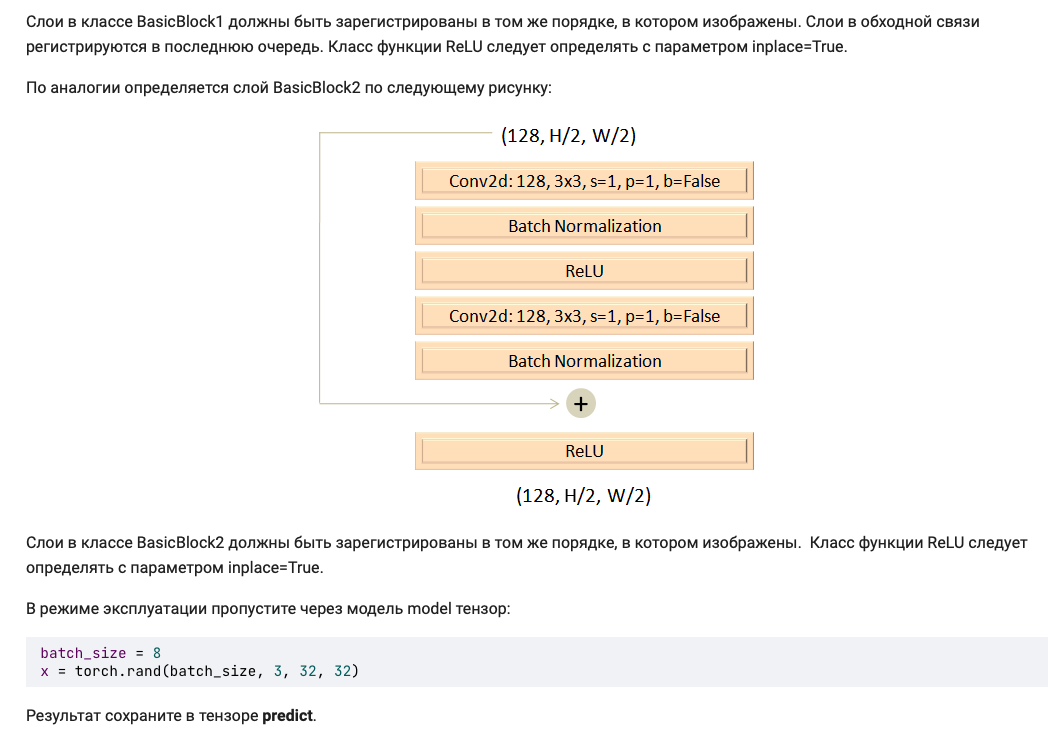

In [22]:
import torch
import torch.nn as nn

# здесь объявляйте классы BasicBlock1 и BasicBlock2

batch_size = 8
x = torch.rand(batch_size, 3, 32, 32) # тензор x в программе не менять

# здесь продолжайте программу
class BasicBlock1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(128)
        self.conv2 = nn.Conv2d(128, 128, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU(inplace=True)

        self.convres = nn.Conv2d(64, 128, 1, stride=2, padding=0, bias=False)
        self.bnres = nn.BatchNorm2d(128)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        identity = self.convres(identity)
        identity = self.bnres(identity)

        x = x + identity
        x = self.relu(x)

        return x
    
class BasicBlock2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(128, 128, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(128)
        self.conv2 = nn.Conv2d(128, 128, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = x + identity
        x = self.relu(x)

        return x
    
model = nn.Sequential(
    nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(3, stride=2, padding=1),
    BasicBlock1(),
    BasicBlock2(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(128, 10)
)

model.eval()
predict = model(x)

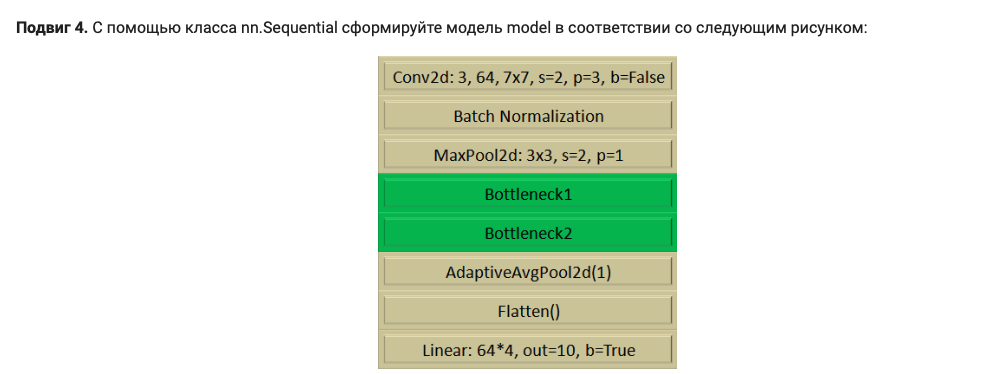
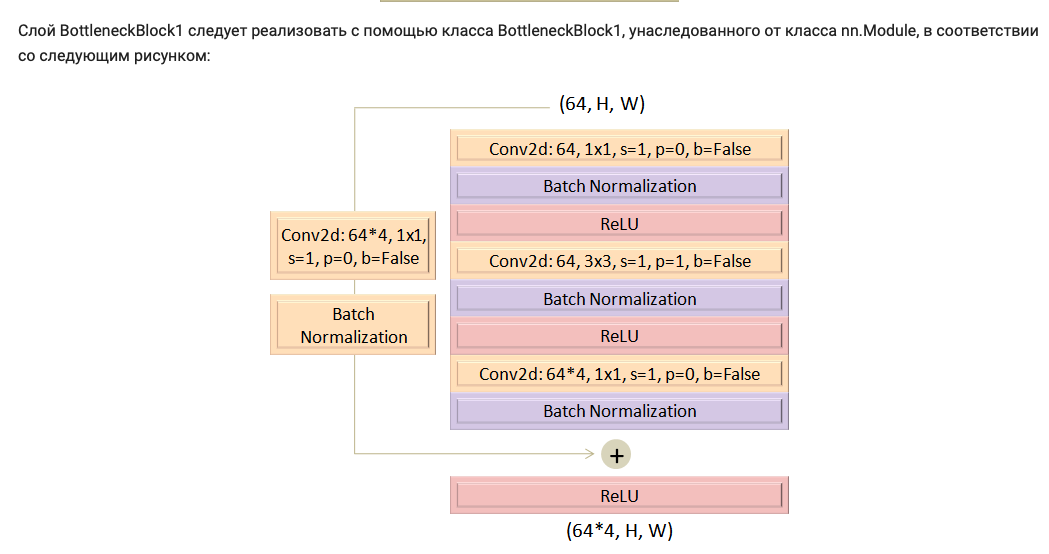
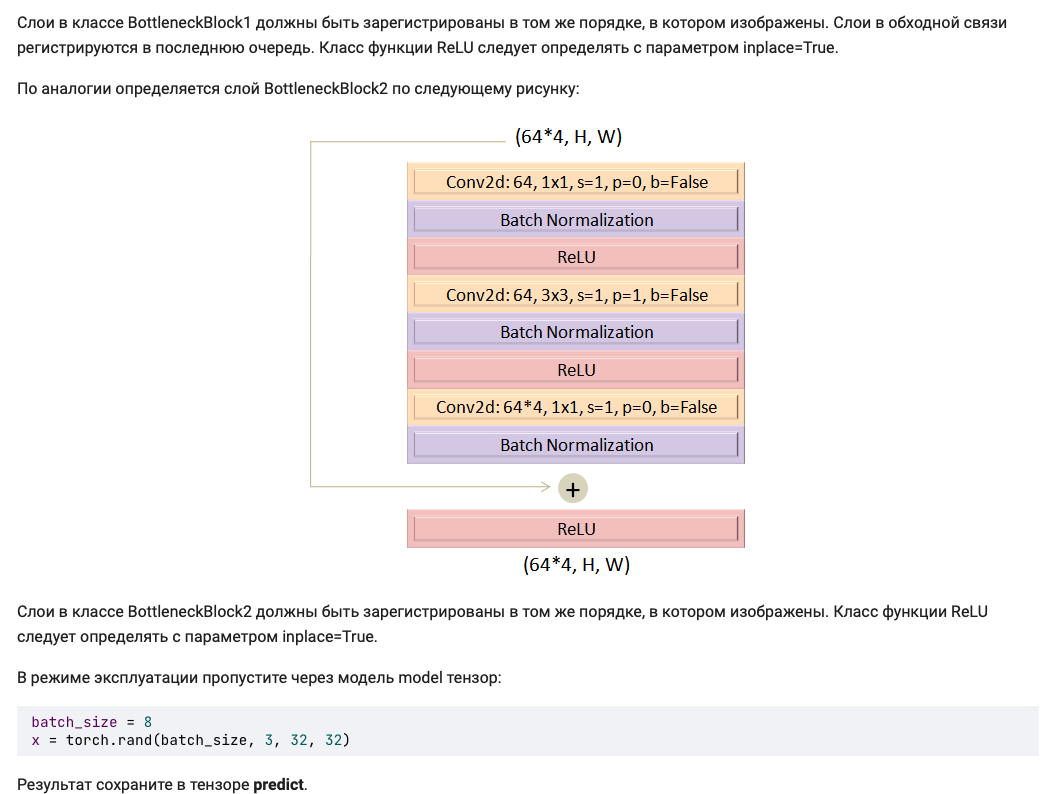

In [26]:
import torch
import torch.nn as nn

# здесь объявляйте классы BottleneckBlock1 и BottleneckBlock2

batch_size = 8
x = torch.rand(batch_size, 3, 32, 32) # тензор x в программе не менять

# здесь продолжайте программу
class BasicBlock1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(64, 64, 1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64*4, 1, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(64*4)
        self.relu = nn.ReLU(inplace=True)

        self.convres = nn.Conv2d(64, 64*4, 1, stride=1, padding=0, bias=False)
        self.bnres = nn.BatchNorm2d(64*4)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)

        identity = self.convres(identity)
        identity = self.bnres(identity)

        x = x + identity
        x = self.relu(x)

        return x
    
class BasicBlock2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(64*4, 64, 1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64*4, 1, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(64*4)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)

        x = x + identity
        x = self.relu(x)

        return x
    
model = nn.Sequential(
    nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(3, stride=2, padding=1),
    BasicBlock1(),
    BasicBlock2(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64*4, 10)
)

model.eval()
predict = model(x)